### Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

### Drug sensitivity info extraction

In [2]:
batch_sen = pd.read_csv("../data/rawdata/uhn_breast/batch_metrics.csv")

# batch name contains PACLITAXEL but not "-"
pax = batch_sen[batch_sen["batch.name"].str.contains("PACLITAXEL") & ~batch_sen["batch.name"].str.contains("-") & ~batch_sen["batch.name"].str.contains("RES")].reset_index(drop=True)

pax["model.id"] = pax["batch.name"].str.split(".").str[0]
pax["drug.id"] = pax["batch.name"].str.split(".").str[1]

mask = pax["model.id"].str.match(r'^\d', na=False)
pax.loc[mask, "model.id"] = "S" + pax.loc[mask, "model.id"]

pax = pax[["model.id", "angle", "mRECIST", "TGI"]].set_index("model.id")
pax.to_csv("../data/procdata/4_paclitaxel/metadata.csv")

### RNAseq data

In [3]:
# read in the RNA-seq data
rna = pd.read_csv("../data/rawdata/uhn_breast/omics/rna_tpm_hugo.tsv", sep="	", index_col=0)

rna = rna.transpose()
print(f"Models in RNA-seq: {len(rna)}")
rna = np.log2(rna + 1)

# remove genes with no variance across all available RNA-seq samples
rna = rna.loc[:, rna.var() > 0]

# merge with paclitaxel response metadata
df_rna_pax = rna.merge(pax, left_index=True, right_index=True, how="inner")

# remove genes with no variance within the paclitaxel subset
response_cols = ["angle", "mRECIST", "TGI"]
X = df_rna_pax.drop(columns=response_cols)
y = df_rna_pax[response_cols]
X = X.loc[:, X.var() > 0]
df_rna_pax = X.merge(y, left_index=True, right_index=True)

print(f"Models in pax list: {len(pax)}")
print(f"Models in Final DF: {df_rna_pax.shape[0]}")
print(f"RNA genes after paclitaxel subset zero-variance filter: {X.shape[1]}")

df_rna_pax.to_csv("../data/procdata/4_paclitaxel/rna_logtpm.csv")
print(df_rna_pax.shape)


Models in RNA-seq: 95
Models in pax list: 80
Models in Final DF: 67
RNA genes after paclitaxel subset zero-variance filter: 49348


(67, 49351)


### CNV data

In [4]:
# read in the CNV data
cnv = pd.read_csv("../data/rawdata/uhn_breast/omics/cnv_hugo.tsv", sep="	", index_col=0)

# transpose to samples x genes
cnv = cnv.transpose()
print(f"Models in CNV before filtering: {len(cnv)}")

# remove genes with high missingness across samples
missing_rate = cnv.isna().mean(axis=0)
missing_rate.to_csv("../data/procdata/4_paclitaxel/cnv_gene_missing_rate.csv")

cnv = cnv.loc[:, missing_rate < 0.20]
print(f"CNV genes after missingness filter: {cnv.shape[1]}")

# impute remaining missing values using sample-wise median copy number
# this preserves sample-level ploidy/aneuploidy better than filling with 2
cnv = cnv.apply(lambda row: row.fillna(row.median()), axis=1)

# remove genes with no variance after imputation across all available CNV samples
cnv = cnv.loc[:, cnv.var() > 0]
print(f"CNV genes after global zero-variance filter: {cnv.shape[1]}")

# merge with paclitaxel response metadata
df_cnv_pax = cnv.merge(pax, left_index=True, right_index=True, how="inner")

# remove genes with no variance within the paclitaxel subset
response_cols = ["angle", "mRECIST", "TGI"]
X = df_cnv_pax.drop(columns=response_cols)
y = df_cnv_pax[response_cols]
X = X.loc[:, X.var() > 0]
df_cnv_pax = X.merge(y, left_index=True, right_index=True)

print(f"Models in pax list: {len(pax)}")
print(f"Models in Final DF: {df_cnv_pax.shape[0]}")
print(f"CNV genes after paclitaxel subset zero-variance filter: {X.shape[1]}")

# save processed CNV + response table
df_cnv_pax.to_csv("../data/procdata/4_paclitaxel/cnv.csv")
print(df_cnv_pax.shape)


Models in CNV before filtering: 94
CNV genes after missingness filter: 10004
CNV genes after global zero-variance filter: 9961
Models in pax list: 80
Models in Final DF: 62
CNV genes after paclitaxel subset zero-variance filter: 9956


(62, 9959)


### Mutation data

In [5]:
# read in the Mutation data
mutation = pd.read_csv("../data/rawdata/uhn_breast/omics/mutation_hugo.tsv", sep="	", index_col=0)

mutation = mutation.transpose()

# Define non-functional terms
non_functional_terms = {"Silent", 
                        "Intron",
                        "3'UTR",
                        "5'UTR",
                        "3'Flank",
                        "5'Flank",
                        "RNA",
                        "IGR",
                        "Targeted_Region"}

def binarize_mutation(val):
    if pd.isna(val) or val == "":
        return 0
    
    # Split by comma in case of multiple annotations (e.g., "Intron,Missense")
    parts = {p.strip() for p in str(val).split(',')}
    
    # If all parts are in the non_functional list, return 0
    if parts.issubset(non_functional_terms):
        return 0
    
    # Otherwise, there is at least one functional mutation
    return 1

# Apply the function (using .map for modern pandas)
mutation = mutation.map(binarize_mutation)

print(f"Models in Mutation: {len(mutation)}")

# remove genes with no variance across all available mutation samples
mutation = mutation.loc[:, mutation.var() > 0]

# merge with paclitaxel response metadata
df_mutation_pax = mutation.merge(pax, left_index=True, right_index=True, how="inner")

# remove genes with no variance within the paclitaxel subset
response_cols = ["angle", "mRECIST", "TGI"]
X = df_mutation_pax.drop(columns=response_cols)
y = df_mutation_pax[response_cols]
X = X.loc[:, X.var() > 0]
df_mutation_pax = X.merge(y, left_index=True, right_index=True)

print(f"Models in pax list: {len(pax)}")
print(f"Models in Final DF: {df_mutation_pax.shape[0]}")
print(f"Mutation genes after paclitaxel subset zero-variance filter: {X.shape[1]}")

df_mutation_pax.to_csv("../data/procdata/4_paclitaxel/mutation.csv")
print(df_mutation_pax.shape)


Models in Mutation: 91
Models in pax list: 80
Models in Final DF: 62
Mutation genes after paclitaxel subset zero-variance filter: 13642
(62, 13645)


            angle        TGI
count   80.000000  80.000000
mean    80.991896   0.546626
std     68.677721   0.434519
min     -6.414003  -1.116709
25%      7.347893   0.409088
50%     89.653284   0.630347
75%    153.436206   0.845969
max    173.936219   1.000000
mRECIST
SD    26
CR    19
PR    18
PD    17
Name: count, dtype: int64
Pearson angle vs TGI: PearsonRResult(statistic=np.float64(0.6429237149219359), pvalue=np.float64(1.27556206832362e-10))
Spearman angle vs TGI: SignificanceResult(statistic=np.float64(0.7447960618846695), pvalue=np.float64(2.370592879526651e-15))
angle KruskalResult(statistic=np.float64(59.125869695606525), pvalue=np.float64(9.036010705179535e-13))
TGI KruskalResult(statistic=np.float64(40.51753126601773), pvalue=np.float64(8.276349525789523e-09))


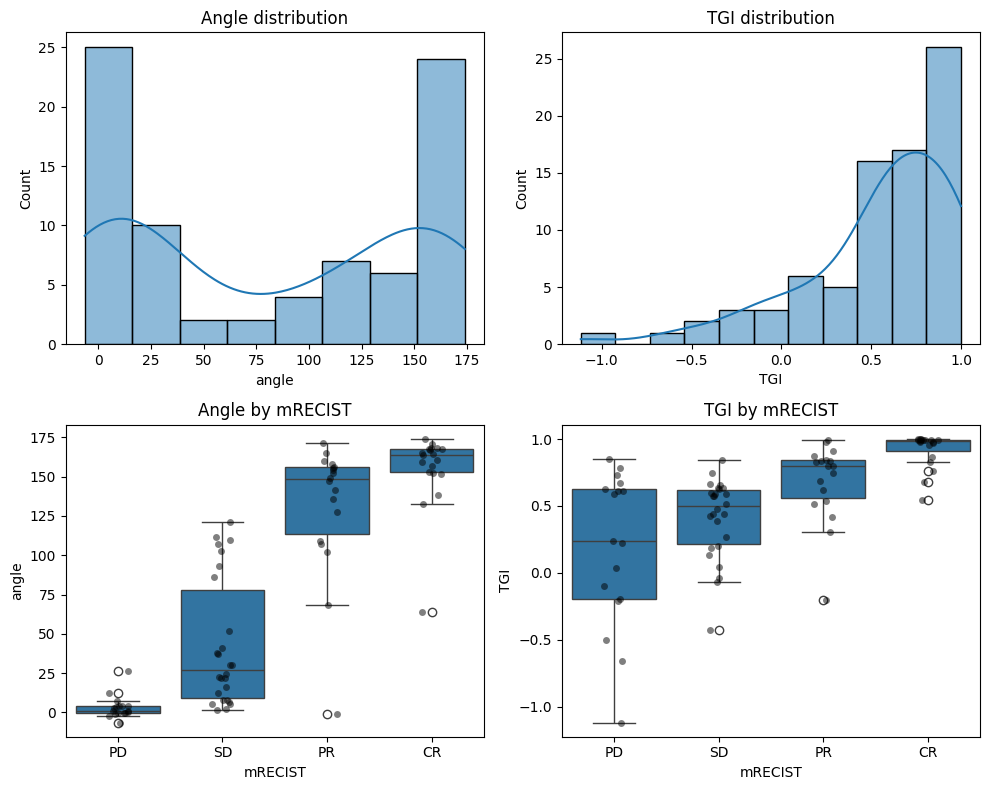

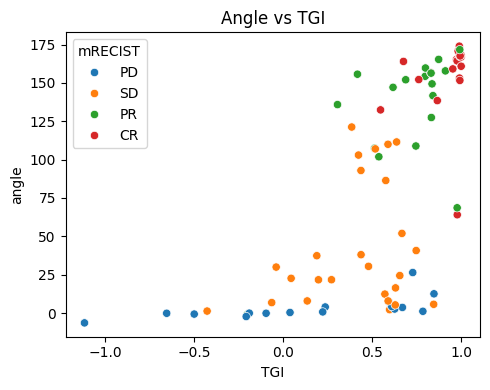

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kruskal

meta = pd.read_csv("../data/procdata/4_paclitaxel/metadata.csv", index_col=0)

order = ["PD", "SD", "PR", "CR"]

print(meta[["angle", "TGI"]].describe())
print(meta["mRECIST"].value_counts())

print("Pearson angle vs TGI:", pearsonr(meta["angle"], meta["TGI"]))
print("Spearman angle vs TGI:", spearmanr(meta["angle"], meta["TGI"]))

for col in ["angle", "TGI"]:
    groups = [meta.loc[meta["mRECIST"] == g, col] for g in order]
    print(col, kruskal(*groups))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(meta["angle"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Angle distribution")

sns.histplot(meta["TGI"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("TGI distribution")

sns.boxplot(data=meta, x="mRECIST", y="angle", order=order, ax=axes[1, 0])
sns.stripplot(data=meta, x="mRECIST", y="angle", order=order, color="black", alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("Angle by mRECIST")

sns.boxplot(data=meta, x="mRECIST", y="TGI", order=order, ax=axes[1, 1])
sns.stripplot(data=meta, x="mRECIST", y="TGI", order=order, color="black", alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title("TGI by mRECIST")

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=meta, x="TGI", y="angle", hue="mRECIST", hue_order=order)
plt.title("Angle vs TGI")
plt.tight_layout()
plt.show()

response_binary
Resistant    43
Sensitive    37
Name: count, dtype: int64


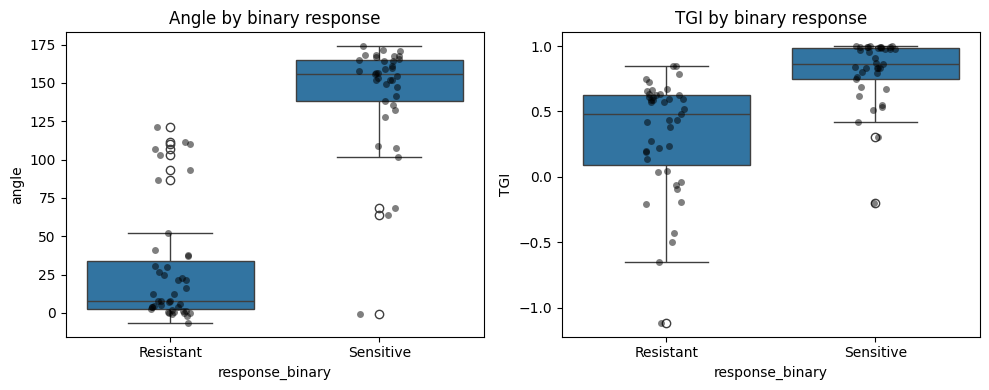


angle
  Resistant median: 7.894
  Sensitive median: 155.670
  Mann-Whitney p: 1.998e-12
  Point-biserial r: 0.848, p=3.307e-23
  AUROC using angle: 0.959
  AUPRC using angle: 0.969

TGI
  Resistant median: 0.479
  Sensitive median: 0.866
  Mann-Whitney p: 6.281e-09
  Point-biserial r: 0.556, p=8.402e-08
  AUROC using TGI: 0.879
  AUPRC using TGI: 0.896


In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.metrics import roc_auc_score, average_precision_score

meta = pd.read_csv("../data/procdata/4_paclitaxel/metadata.csv", index_col=0)

# Binary response label
meta["response_binary"] = meta["mRECIST"].map({
    "PD": "Resistant",
    "SD": "Resistant",
    "PR": "Sensitive",
    "CR": "Sensitive"
})

meta["response_binary_num"] = meta["response_binary"].map({
    "Resistant": 0,
    "Sensitive": 1
})

print(meta["response_binary"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=meta, x="response_binary", y="angle", order=["Resistant", "Sensitive"], ax=axes[0])
sns.stripplot(data=meta, x="response_binary", y="angle", order=["Resistant", "Sensitive"],
              color="black", alpha=0.5, ax=axes[0])
axes[0].set_title("Angle by binary response")

sns.boxplot(data=meta, x="response_binary", y="TGI", order=["Resistant", "Sensitive"], ax=axes[1])
sns.stripplot(data=meta, x="response_binary", y="TGI", order=["Resistant", "Sensitive"],
              color="black", alpha=0.5, ax=axes[1])
axes[1].set_title("TGI by binary response")

plt.tight_layout()
plt.show()

for metric in ["angle", "TGI"]:
    resistant = meta.loc[meta["response_binary"] == "Resistant", metric]
    sensitive = meta.loc[meta["response_binary"] == "Sensitive", metric]

    u_stat, p_val = mannwhitneyu(resistant, sensitive, alternative="two-sided")
    corr, corr_p = pointbiserialr(meta["response_binary_num"], meta[metric])

    auc = roc_auc_score(meta["response_binary_num"], meta[metric])
    auprc = average_precision_score(meta["response_binary_num"], meta[metric])

    print(f"\n{metric}")
    print(f"  Resistant median: {resistant.median():.3f}")
    print(f"  Sensitive median: {sensitive.median():.3f}")
    print(f"  Mann-Whitney p: {p_val:.3e}")
    print(f"  Point-biserial r: {corr:.3f}, p={corr_p:.3e}")
    print(f"  AUROC using {metric}: {auc:.3f}")
    print(f"  AUPRC using {metric}: {auprc:.3f}")